In [1]:
import torch
from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader
import torch.nn as nn
import torch.optim as optim
import numpy as np
import os

In [2]:
data_transfomrs = {
    'train': transforms.Compose([
        transforms.RandomResizedCrop(224),
        transforms.RandomHorizontalFlip(),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ]),
    'val': transforms.Compose([
        transforms.Resize(256),
        transforms.CenterCrop(224),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ]),
    'test': transforms.Compose([
        transforms.Resize(256),
        transforms.CenterCrop(224),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ])
}

In [3]:
data_dir = "C:/Users/abedi/OneDrive/Desktop/ResNET_PyTorch/data"

In [4]:
os.listdir(data_dir)

['test', 'train', 'val']

In [5]:
sets = ['train', 'val', 'test']

image_datasets = {x: datasets.ImageFolder(os.path.join(data_dir,x), data_transfomrs[x]) for x in sets}
dataloaders = {x: DataLoader(image_datasets[x], batch_size=32, shuffle=True, num_workers=4) for x in sets}
dataset_sizes = {x: len(image_datasets[x]) for x in sets}
class_names = image_datasets['train'].classes

In [6]:
device = "cuda" if torch.cuda.is_available() else "cpu"
device

'cpu'

In [7]:
#load pre trained model
model_ft = models.resnet18(pretrained=True)
num_ftrs = model_ft.fc.in_features
model_ft.fc = nn.Linear(num_ftrs, len(class_names))

model_ft.to(device)

criterion = nn.CrossEntropyLoss()
optimizer_ft = optim.SGD(model_ft.parameters(), lr=0.001, momentum=0.9)

c:\Users\abedi\OneDrive\Desktop\ResNET_PyTorch\venv\Lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
c:\Users\abedi\OneDrive\Desktop\ResNET_PyTorch\venv\Lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


In [8]:
import time
import copy

def train_model(model, criterion, optimizer, num_epochs=25):
    best_model_wts = copy.deepcopy(model.state_dict())
    best_acc = 0

    for epoch in range(num_epochs):
        print(f"Epoch {epoch}/{num_epochs -1}")
        print("----------------------------------------")

        for phase in ['train', 'val']:
            if phase == 'train':
                model.train()
            else:
                model.eval()

            running_loss = 0.0
            running_corrects = 0

            for inputs, labels in dataloaders[phase]:
                inputs = inputs.to(device)
                labels = labels.to(device)

                optimizer.zero_grad()


                with torch.set_grad_enabled(phase =='train'):
                    outputs = model(inputs)
                    _, preds = torch.max(outputs,1)
                    loss = criterion(outputs, labels)

                    if phase == 'train':
                        loss.backward()
                        optimizer.step()

                running_loss += loss.item() * inputs.size(0)
                running_corrects += torch.sum(preds == labels.data)

            epoch_loss = running_loss / dataset_sizes[phase]
            epoch_acc = running_corrects.double() / dataset_sizes[phase]

            print(f"{phase}, Loss: {epoch_loss:.4f} Acc: {epoch_acc:.4f}")

            if phase == 'val' and epoch_loss > best_acc:
                best_acc = epoch_acc
                best_model_wts = copy.deepcopy(model.state_dict())

        print()
    print(f"Best val acc: {best_acc:4f}")

    model.load_state_dict(best_model_wts)
    return model

In [9]:
model_ft = train_model(model_ft, criterion, optimizer_ft, num_epochs=25)

Epoch 0/24
----------------------------------------
train, Loss: 2.6642 Acc: 0.3592
val, Loss: 1.1452 Acc: 0.7208

Epoch 1/24
----------------------------------------
train, Loss: 1.3155 Acc: 0.6909
val, Loss: 0.5449 Acc: 0.8661

Epoch 2/24
----------------------------------------
train, Loss: 0.9332 Acc: 0.7669
val, Loss: 0.3783 Acc: 0.8718

Epoch 3/24
----------------------------------------
train, Loss: 0.8013 Acc: 0.7778
val, Loss: 0.3243 Acc: 0.8917

Epoch 4/24
----------------------------------------
train, Loss: 0.6726 Acc: 0.8183
val, Loss: 0.2880 Acc: 0.9003

Epoch 5/24
----------------------------------------
train, Loss: 0.6057 Acc: 0.8311
val, Loss: 0.2609 Acc: 0.9003

Epoch 6/24
----------------------------------------
train, Loss: 0.5617 Acc: 0.8395
val, Loss: 0.2561 Acc: 0.9088

Epoch 7/24
----------------------------------------
train, Loss: 0.5062 Acc: 0.8520
val, Loss: 0.2593 Acc: 0.9031

Epoch 8/24
----------------------------------------
train, Loss: 0.4746 Acc: 0.8

In [10]:
def evaluate_model(model):
    model.eval()
    running_corrects = 0

    for inputs,labels in dataloaders['test']:
        inputs = inputs.to(device)
        labels = labels.to(device)

        with torch.no_grad():
            outpus = model(inputs)
            _, preds = torch.max(outpus, 1)

        running_corrects += torch.sum(preds == labels.data)

    test_acc = running_corrects.double() / dataset_sizes['test']

    print(f"Test Acc: {test_acc:.4f}")

evaluate_model(model_ft)

Test Acc: 0.7214


In [11]:
torch.save(model_ft, "fruits_and_vegetables_model.pth")

In [13]:
loaded_model = torch.load("fruits_and_vegetables_model.pth", weights_only=False)

In [14]:
loaded_model.eval()

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

In [15]:
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt

In [16]:
def load_image(image_path):
    transform = transforms.Compose([
        transforms.Resize(256),
        transforms.CenterCrop(224),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ])

    image = Image.open(image_path)
    image = transform(image).unsqueeze(0)
    return image

In [17]:
def imshow(inp, title=None):
    inp = inp.numpy().transpose((1,2,0))
    mean = np.array([0.485, 0.456, 0.406])
    std = np.array([0.229, 0.224, 0.225])
    inp = std * inp + mean
    inp = np.clip(inp, 0,1)
    plt.imshow(inp)
    if title is not None:
        plt.title(title)
    
    plt.pause(0.001)

In [18]:
def predict_image(model, image):
    model.eval()
    image = image.to(device)
    with torch.no_grad():
        outputs = model(image)
        _, preds = torch.max(outputs, 1)
    return class_names[preds[0]], preds[0]

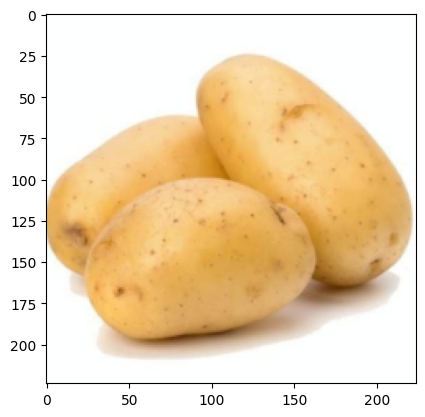

Predicted class: potato, Index: 27


In [23]:
image_path = "C:/Users/abedi/OneDrive/Desktop/ResNET_PyTorch/potato.jpg"
image = load_image(image_path)

plt.figure()
imshow(image.squeeze())
plt.show()

predicted_class, predicted_class_idx = predict_image(loaded_model, image)
print(f"Predicted class: {predicted_class}, Index: {predicted_class_idx}")